# Compare the peak to trough ratios of our deconvolution runs

1. Load the model 
2. Load the raw data
3. Load the deconvolved data
4. Compute the peak to trough ratio
5. Load the published peak to trough ratio values
6. Plot the comparison between the peak to trough ratios


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [3]:
from cc_src.deconvolution_analysis import DeconvolvedAnalysis
from src.config import Config, load_xg_gene_expression_config
from src.model import Model

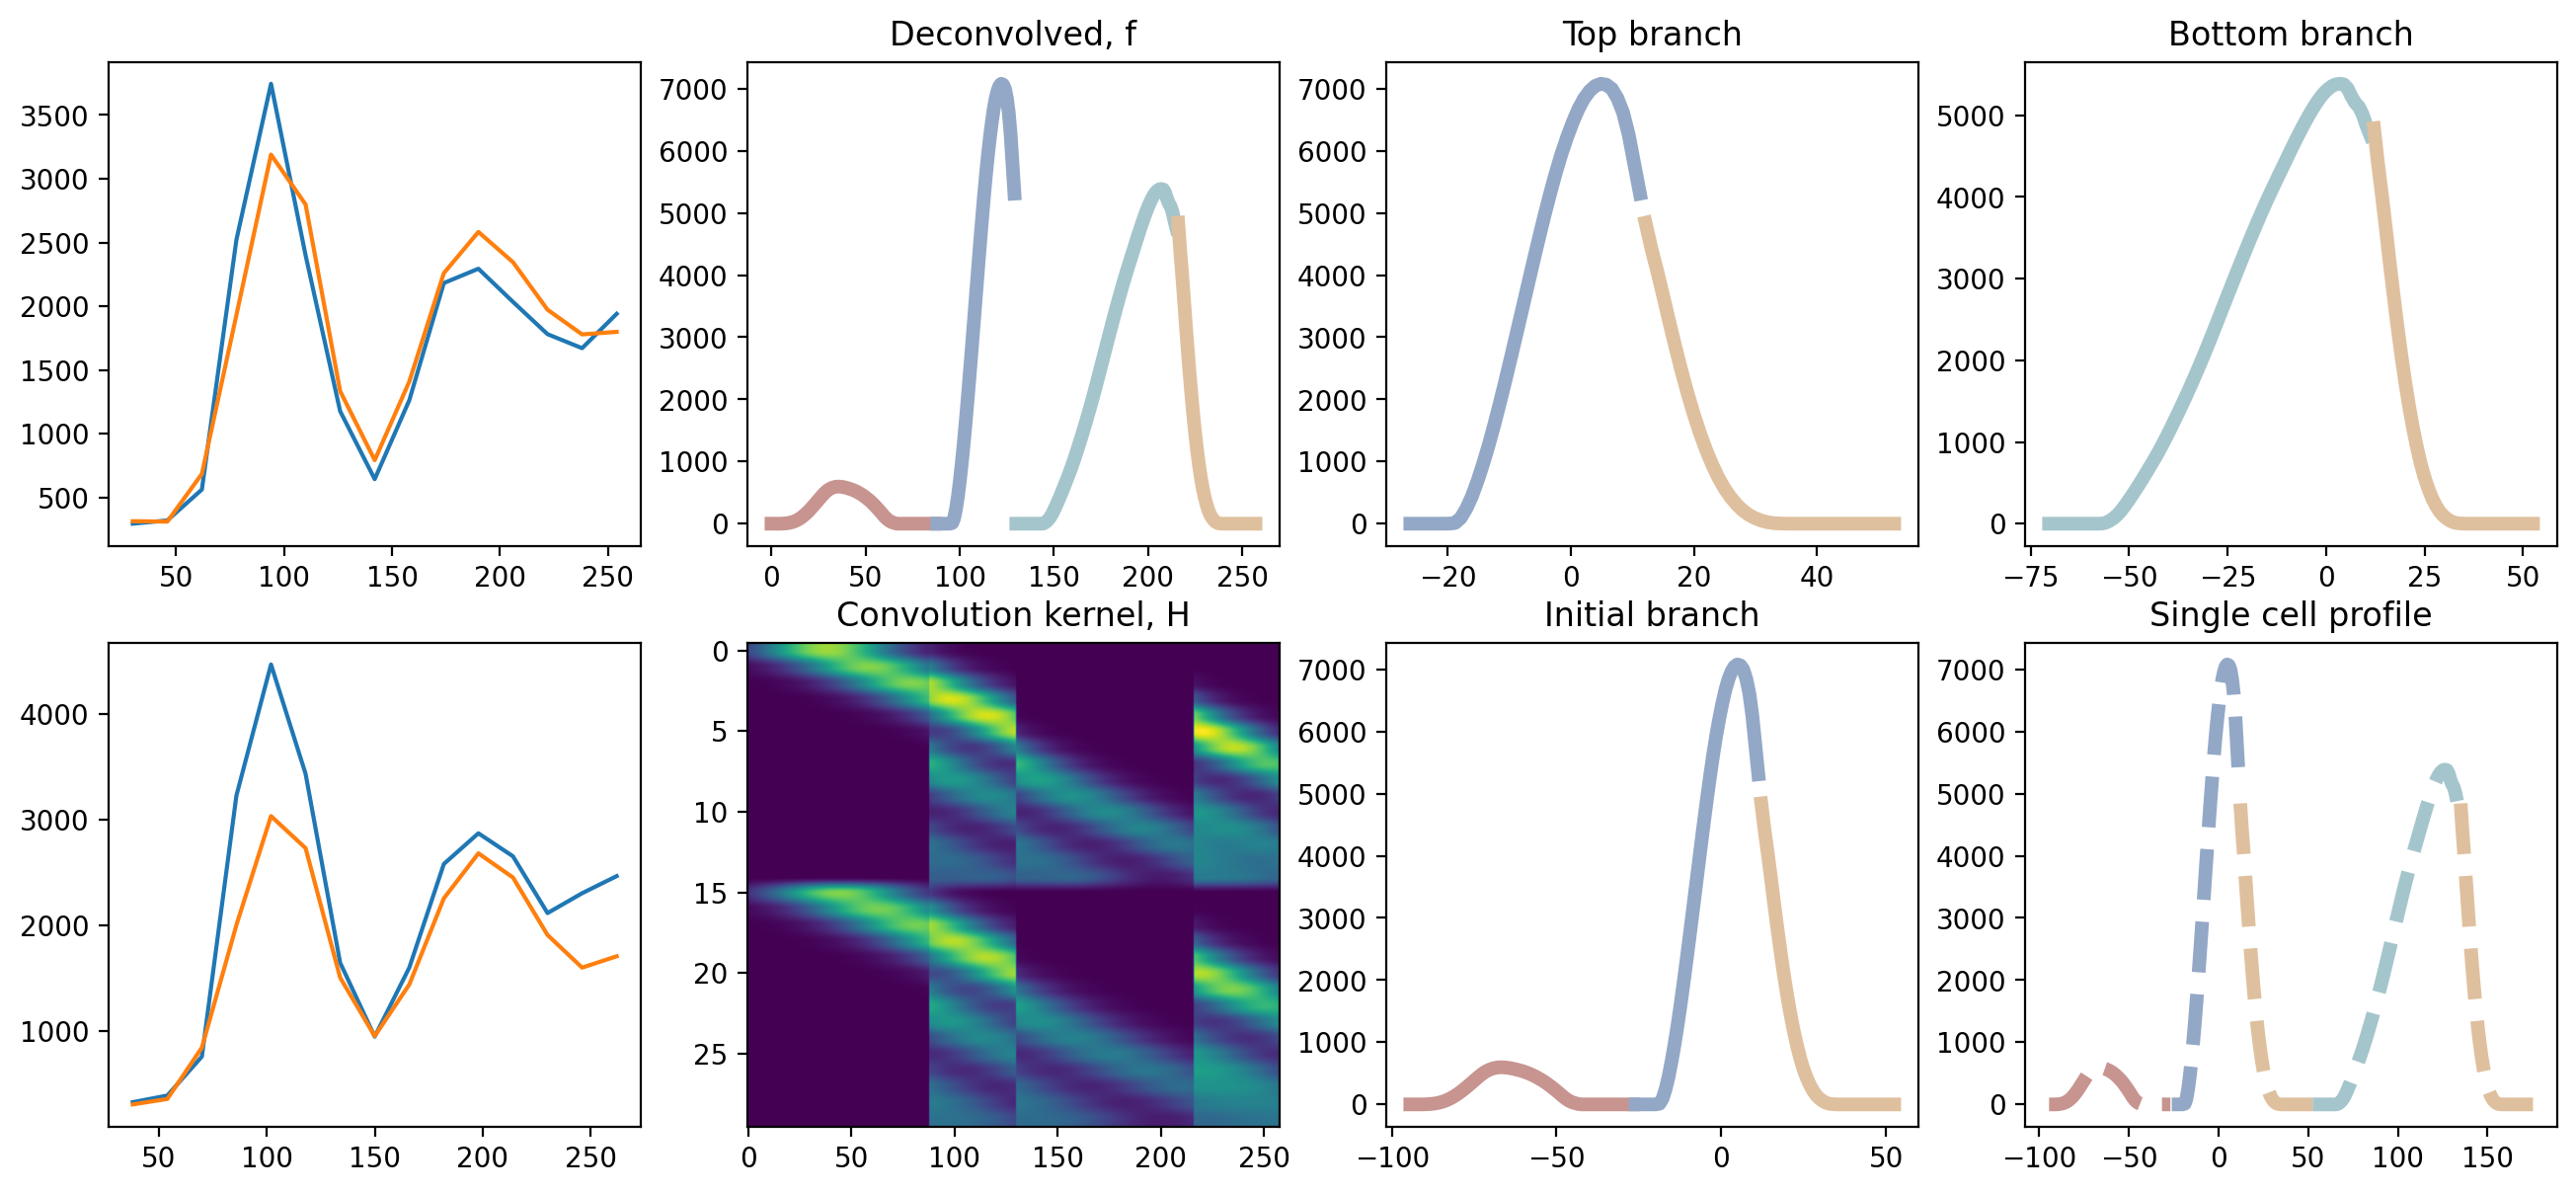

In [204]:
from cc_src.sgd import get_orfname

gene_name = 'CLN2'
orf_name = get_orfname(gene_name)
gamma = 0.004

config = load_xg_gene_expression_config()
model = Model(config, gene_name, gamma)

deconvolved_analysis = DeconvolvedAnalysis(model)
deconvolved_analysis.plot_deconvolved_gene(gene_name)

In [211]:
gene_f = deconvolved_analysis.f.loc[orf_name].values

In [212]:
compute_ptr(model, gene_f)

4713.40706010903

In [12]:
genelist = pd.read_csv('allgenes/commongenelist.txt',sep='\t', header=None)[0].values

In [28]:
gene_f = deconvolved_analysis.f.loc[orf_name].values

In [134]:
ptrs = deconvolved_analysis.f[[]].copy()

for orf_name, row in deconvolved_analysis.f.iterrows():
    
    dec_ptr = compute_ptr(row)
    ptrs.loc[orf_name, 'ptr'] = dec_ptr


ptrs.head()

,ptr
orf_name,
YPR161C,1.204751
YOL138C,1.051088
YDR395W,1.122499
YGR129W,1.541353
YPR165W,1.255229


In [94]:
matlab_fs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_f.csv', header=None)
matlab_gs.index = deconvolved_analysis.f.index
matlab_gs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_g.csv', header=None)
matlab_fs.index = deconvolved_analysis.f.index

In [123]:
# matlab_f = matlab_fs.loc[orf_name]
# plt.plot(matlab_f)
# plt.plot(gene_f)

In [103]:
gene_table_path = '/Users/trung/Research/cell-cycle/data/dataset_from_deconv_web/gene_associated.tsv';
gene_table = pd.read_csv(gene_table_path, sep='\t');
gene_table = gene_table[['Systematic Name', 'Deconvolved PTR (80pt/20pt)']].set_index('Systematic Name')
gene_table.head(2)

,Deconvolved PTR (80pt/20pt)
Systematic Name,
YKR013W,14716.721
YIL140W,7425.072


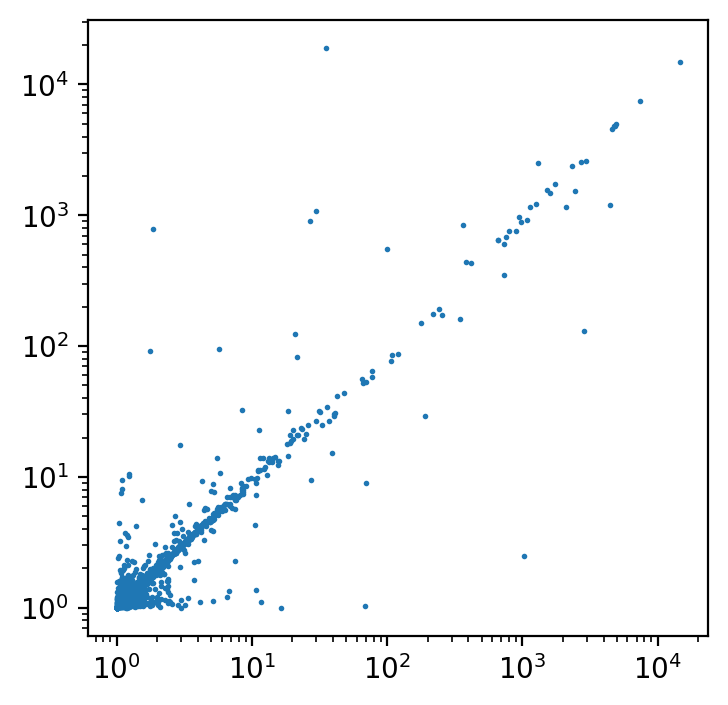

In [141]:
plt_data = gene_table.join(ptrs)

plt.figure(figsize=(4, 4))
plt.scatter(plt_data['Deconvolved PTR (80pt/20pt)'], plt_data.ptr, s=1)
plt.xscale('log')
plt.yscale('log')

# a decent set of genes with different PTR values, wonder if it's the scaling thing, maybe something else.
# We can investigate tomorrow.


In [182]:
matlab_peaktotroughts = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/peak2troughs.csv', header=None)
matlab_peaktotroughts.index = deconvolved_analysis.f.index
matlab_peaktotroughts.columns = ['ptr']

In [184]:
comparison_ptrs_py_matlab = ptrs.join(matlab_peaktotroughts, lsuffix='_py', rsuffix='_matlab')

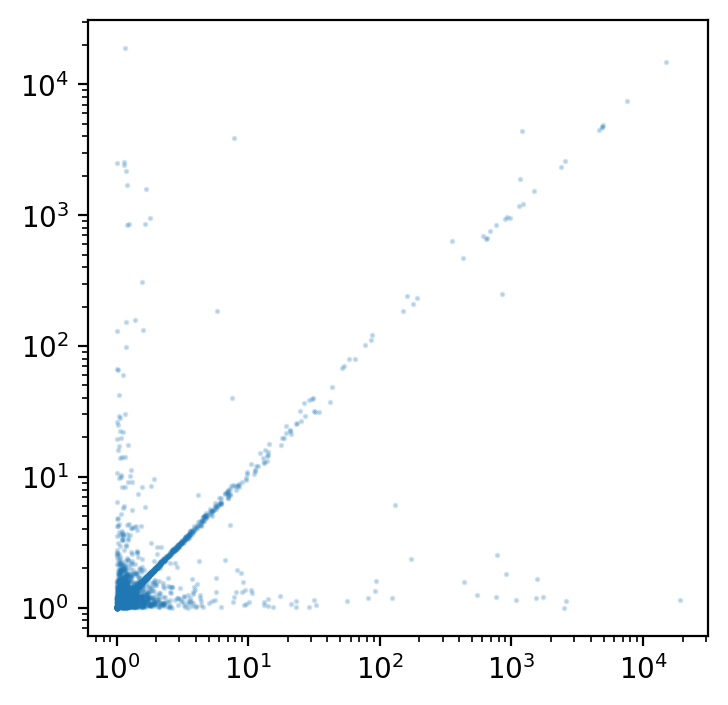

In [190]:
plt.figure(figsize=(4, 4))
plt.scatter(comparison_ptrs_py_matlab.ptr_py, 
            comparison_ptrs_py_matlab.ptr_matlab, s=1, alpha=0.2)
plt.xscale('log')
plt.yscale('log')



In [191]:
comparison_ptrs_py_matlab.ptr_py.corr(comparison_ptrs_py_matlab.ptr_matlab)

0.4920997421426804

In [194]:
comparison_ptrs_py_matlab['diff'] = comparison_ptrs_py_matlab.ptr_py - comparison_ptrs_py_matlab.ptr_matlab

In [200]:
from cc_src.sgd import read_sgd_genes

genes = read_sgd_genes()[['gene']]

In [201]:
comparison_ptrs_py_matlab.sort_values('diff').join(genes)

,ptr_py,ptr_matlab,diff,gene
orf_name,,,,
YBR117C,1.151765,19093.787116,-19092.635350,TKL2
YPL141C,7.756021,3897.655383,-3889.899362,FRK1
YBL035C,1205.847437,4420.186882,-3214.339445,POL12
YJR105W,1.130963,2561.478474,-2560.347511,ADO1
YEL054C,1.003519,2491.414025,-2490.410507,RPL12A
...,...,...,...,...
YDL227C,1573.908748,1.671741,1572.237007,HO
YNR067C,1745.906992,1.201600,1744.705391,DSE4
YEL076C-A,2516.564246,1.003539,2515.560707,None


In [220]:
gene_table.columns = ['web_ptr']
web_ptr_table = gene_table

comparison_ptrs_py_matlab_web = comparison_ptrs_py_matlab.join(web_ptr_table)

Text(0, 0.5, 'Published PTR')

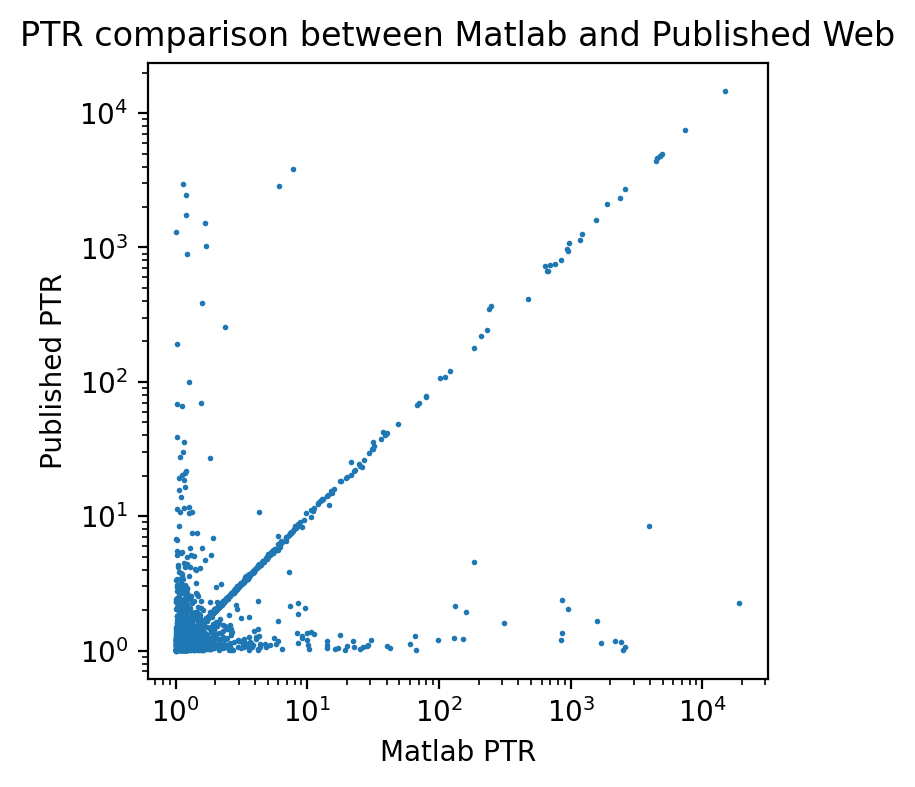

In [228]:
comparison_ptrs_py_matlab_web

plt.figure(figsize=(4,4))
plt.scatter(comparison_ptrs_py_matlab_web.ptr_matlab, 
            comparison_ptrs_py_matlab_web.web_ptr, s=1)
plt.xscale('log')
plt.yscale('log')
plt.title('PTR comparison between Matlab and Published Web')
plt.xlabel("Matlab PTR")
plt.ylabel("Published PTR")